<a href="https://colab.research.google.com/github/omarilzz/Incident-Duration-Data-Audit/blob/main/INC_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Incident Duration Prediction Model

In [7]:
#Expermintal

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('loud_outages_dataset.csv')

In [10]:
df.head(10)

,incident_id,cloud_provider,region,service,service_subtype,start_time,end_time,duration_minutes,severity,status,...,post_mortem_link,is_recurrent_issue,previous_incident_id,external_factors,scheduled_maintenance_conflict,patch_applied,system_load_before_outage,system_load_after_outage,backup_system_triggered,notes
0,aeb380d2-6559-4d99-abfb-17e1c45e831b,AWS,europe-west2,Storage,S3,2025-06-30 10:18:08.524480,2025-06-30 13:15:08.524480,177,Low,Monitoring,...,NaN,No,NaN,NaN,No,No,40,46,Yes,Simulated note
1,ddf7e3a0-f44d-4c94-ae32-189213321e2d,IBM,asia-southeast1,AI/ML,RDS,2025-06-28 10:18:08.524591,2025-06-28 20:52:08.524591,634,Low,Investigating,...,NaN,No,NaN,Weather,Yes,No,45,55,Yes,Simulated note
2,b17b9c80-94a0-4ca5-b52f-f1e7853b1240,AWS,europe-west2,Storage,S3,2025-06-01 10:18:08.524638,2025-06-01 14:36:08.524638,258,High,Resolved,...,NaN,No,NaN,DDoS,No,Yes,61,74,No,Simulated note
3,c856b404-e22e-4f84-8bed-9b1512adc9b5,AWS,asia-southeast1,Compute,Lambda,2025-11-30 10:18:08.524678,2025-11-30 19:21:08.524678,543,Medium,Resolved,...,NaN,Yes,NaN,Weather,No,Yes,48,97,Yes,Simulated note
4,42a85996-663a-4f92-94e1-0f205a06db01,IBM,asia-southeast1,AI/ML,Cloud Functions,2025-02-16 10:18:08.524719,2025-02-16 21:03:08.524719,645,Medium,Monitoring,...,NaN,No,NaN,DDoS,No,No,23,75,Yes,Simulated note
5,cc27ddaf-1511-4714-864f-133d6e946189,Oracle,asia-southeast1,Storage,Lambda,2025-04-14 10:18:08.524774,2025-04-14 19:20:08.524774,542,High,Resolved,...,NaN,Yes,NaN,Weather,Yes,No,93,82,Yes,Simulated note
6,5b0cae72-670c-47a5-b95f-a479f18e85e8,IBM,us-west-2,Compute,BigQuery,2025-03-04 10:18:08.524804,2025-03-04 17:31:08.524804,433,Critical,Investigating,...,NaN,No,NaN,Vendor,No,No,78,15,Yes,Simulated note
7,eeab6d5c-123a-4d04-890c-542a7c4f31d1,IBM,us-west-2,AI/ML,Cloud Functions,2025-07-08 10:18:08.524843,2025-07-08 14:53:08.524843,275,High,Investigating,...,NaN,Yes,NaN,DDoS,Yes,Yes,93,29,No,Simulated note
8,f5d0ef44-604f-4a1d-8206-ae003eb9a75a,GCP,asia-southeast1,Storage,Lambda,2025-04-24 10:18:08.524876,2025-04-24 20:47:08.524876,629,Medium,Resolved,...,NaN,No,NaN,DDoS,No,No,47,88,Yes,Simulated note
9,357abdce-e35e-4312-a379-7a210768239d,IBM,asia-southeast1,Database,Cloud Functions,2026-02-03 10:18:08.524916,2026-02-03 12:27:08.524916,129,Medium,Resolved,...,NaN,Yes,NaN,Vendor,Yes,Yes,87,100,Yes,Simulated note


In [11]:
df.tail(10)

,incident_id,cloud_provider,region,service,service_subtype,start_time,end_time,duration_minutes,severity,status,...,post_mortem_link,is_recurrent_issue,previous_incident_id,external_factors,scheduled_maintenance_conflict,patch_applied,system_load_before_outage,system_load_after_outage,backup_system_triggered,notes
49990,9d4b6fb7-033b-4f27-a19a-eff3399b7c55,GCP,us-west-2,Networking,Lambda,2025-04-20 10:18:11.651426,2025-04-20 20:55:11.651426,637,High,Monitoring,...,NaN,No,NaN,Vendor,Yes,No,80,43,Yes,Simulated note
49991,e61c4afc-48b6-4fd6-b4c8-c3c55649f316,Oracle,asia-southeast1,Networking,VPC,2025-10-30 10:18:11.651452,2025-10-30 17:44:11.651452,446,Critical,Investigating,...,NaN,No,NaN,Vendor,Yes,Yes,44,76,Yes,Simulated note
49992,aa9e88b3-ed74-4f54-8b01-906f81125c33,AWS,us-east-1,Storage,RDS,2025-03-24 10:18:11.651480,2025-03-24 15:58:11.651480,340,Low,Monitoring,...,NaN,Yes,NaN,Weather,Yes,Yes,65,86,No,Simulated note
49993,bf1324b8-d201-4c2d-a165-846903a363f8,AWS,europe-west2,AI/ML,EC2,2025-02-18 10:18:11.651508,2025-02-18 13:18:11.651508,180,Low,Investigating,...,NaN,No,NaN,DDoS,Yes,Yes,68,33,No,Simulated note
49994,d5d81b48-abb9-424c-8cc0-96d9b1791e87,AWS,asia-southeast1,Storage,Cloud Functions,2025-10-16 10:18:11.651535,2025-10-16 15:57:11.651535,339,Medium,Investigating,...,NaN,Yes,NaN,NaN,No,No,56,15,No,Simulated note
49995,2c5b0605-1c5f-4e71-8aff-7dab9221c9f1,AWS,us-west-2,Networking,RDS,2025-12-01 10:18:11.651560,2025-12-01 10:33:11.651560,15,Low,Monitoring,...,NaN,No,NaN,DDoS,No,No,12,94,No,Simulated note
49996,aab03d24-cf9e-40f7-bebf-69b3e3ab29fd,Azure,us-east-1,AI/ML,BigQuery,2025-12-27 10:18:11.651587,2025-12-27 12:02:11.651587,104,Critical,Investigating,...,NaN,No,NaN,Weather,Yes,Yes,12,45,No,Simulated note
49997,740000a8-c9c5-4a1f-b455-948cc64da7de,AWS,europe-west2,Compute,BigQuery,2025-10-16 10:18:11.651615,2025-10-16 20:08:11.651615,590,Medium,Investigating,...,NaN,No,NaN,Vendor,No,Yes,23,62,Yes,Simulated note
49998,8c9bfbd1-9adb-45b6-add4-e7af08af4b22,Azure,us-west-2,Networking,S3,2025-04-05 10:18:11.651645,2025-04-05 15:48:11.651645,330,High,Investigating,...,NaN,Yes,NaN,NaN,Yes,Yes,67,77,No,Simulated note
49999,b94c1c5b-4b40-4d53-8c64-29f2cb38461e,IBM,us-west-2,AI/ML,BigQuery,2025-08-29 10:18:11.651680,2025-08-29 21:45:11.651680,687,High,Investigating,...,NaN,Yes,NaN,DDoS,No,No,87,16,No,Simulated note


In [12]:
print("Datasize:")
print("_________")
print(f"Dataset Shape: {df.shape}\n")
print("_________")
print("--- Missing Values Count ---")
print("_________")
print(df.isnull().sum())

Datasize:
_________
Dataset Shape: (50000, 40)

_________
--- Missing Values Count ---
_________
incident_id                           0
cloud_provider                        0
region                                0
service                               0
service_subtype                       0
start_time                            0
end_time                              0
duration_minutes                      0
severity                              0
status                                0
root_cause_category                   0
root_cause_description                0
number_of_customers_affected          0
estimated_revenue_loss_usd            0
sla_violation                         0
region_impact_score                   0
service_impact_score                  0
ticket_count                          0
ticket_response_time_minutes          0
ticket_resolution_time_minutes        0
monitoring_alerts_triggered           0
detection_method                      0
mitigation_action      

In [13]:
#file has nulls

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   incident_id                     50000 non-null  object 
 1   cloud_provider                  50000 non-null  object 
 2   region                          50000 non-null  object 
 3   service                         50000 non-null  object 
 4   service_subtype                 50000 non-null  object 
 5   start_time                      50000 non-null  object 
 6   end_time                        50000 non-null  object 
 7   duration_minutes                50000 non-null  int64  
 8   severity                        50000 non-null  object 
 9   status                          50000 non-null  object 
 10  root_cause_category             50000 non-null  object 
 11  root_cause_description          50000 non-null  object 
 12  number_of_customers_affected    

In [15]:
#Creating a clean ver.
df_cleaned = df.copy()

#checking_notes_suspecting_zero_variance

print(df_cleaned['notes'].unique())

#Dropping the nulls and overweights

df_cleaned.drop(columns=['post_mortem_link', 'previous_incident_id', 'notes'], inplace=True, errors='ignore')

#filling the missing values in ext_factors

df_cleaned['external_factors'] = df_cleaned['external_factors'].fillna('Unknown')

#Null check
print(df_cleaned.isnull().sum())



['Simulated note']
incident_id                       0
cloud_provider                    0
region                            0
service                           0
service_subtype                   0
start_time                        0
end_time                          0
duration_minutes                  0
severity                          0
status                            0
root_cause_category               0
root_cause_description            0
number_of_customers_affected      0
estimated_revenue_loss_usd        0
sla_violation                     0
region_impact_score               0
service_impact_score              0
ticket_count                      0
ticket_response_time_minutes      0
ticket_resolution_time_minutes    0
monitoring_alerts_triggered       0
detection_method                  0
mitigation_action                 0
number_of_engineers_involved      0
engineer_response_time_minutes    0
communication_channels_used       0
public_status_page_updated        0
status_pa

In [16]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   incident_id                     50000 non-null  object 
 1   cloud_provider                  50000 non-null  object 
 2   region                          50000 non-null  object 
 3   service                         50000 non-null  object 
 4   service_subtype                 50000 non-null  object 
 5   start_time                      50000 non-null  object 
 6   end_time                        50000 non-null  object 
 7   duration_minutes                50000 non-null  int64  
 8   severity                        50000 non-null  object 
 9   status                          50000 non-null  object 
 10  root_cause_category             50000 non-null  object 
 11  root_cause_description          50000 non-null  object 
 12  number_of_customers_affected    

In [17]:
for col in df_cleaned:
    print(f"--- Column: {col} ---")
    print(df_cleaned[col].unique())
    print("\n")

--- Column: incident_id ---
['aeb380d2-6559-4d99-abfb-17e1c45e831b'
 'ddf7e3a0-f44d-4c94-ae32-189213321e2d'
 'b17b9c80-94a0-4ca5-b52f-f1e7853b1240' ...
 '740000a8-c9c5-4a1f-b455-948cc64da7de'
 '8c9bfbd1-9adb-45b6-add4-e7af08af4b22'
 'b94c1c5b-4b40-4d53-8c64-29f2cb38461e']


--- Column: cloud_provider ---
['AWS' 'IBM' 'Oracle' 'GCP' 'Azure']


--- Column: region ---
['europe-west2' 'asia-southeast1' 'us-west-2' 'us-east-1']


--- Column: service ---
['Storage' 'AI/ML' 'Compute' 'Database' 'Networking']


--- Column: service_subtype ---
['S3' 'RDS' 'Lambda' 'Cloud Functions' 'BigQuery' 'VPC' 'EC2']


--- Column: start_time ---
['2025-06-30 10:18:08.524480' '2025-06-28 10:18:08.524591'
 '2025-06-01 10:18:08.524638' ... '2025-10-16 10:18:11.651615'
 '2025-04-05 10:18:11.651645' '2025-08-29 10:18:11.651680']


--- Column: end_time ---
['2025-06-30 13:15:08.524480' '2025-06-28 20:52:08.524591'
 '2025-06-01 14:36:08.524638' ... '2025-10-16 20:08:11.651615'
 '2025-04-05 15:48:11.651645' '2025-

In [18]:
df_cleaned = df_cleaned.drop(columns=['incident_id', 'root_cause_description'], errors='ignore')

In [19]:
for col in df_cleaned:
    print(f"--- Column: {col} ---")
    print(df_cleaned[col].unique())
    print("\n")

--- Column: cloud_provider ---
['AWS' 'IBM' 'Oracle' 'GCP' 'Azure']


--- Column: region ---
['europe-west2' 'asia-southeast1' 'us-west-2' 'us-east-1']


--- Column: service ---
['Storage' 'AI/ML' 'Compute' 'Database' 'Networking']


--- Column: service_subtype ---
['S3' 'RDS' 'Lambda' 'Cloud Functions' 'BigQuery' 'VPC' 'EC2']


--- Column: start_time ---
['2025-06-30 10:18:08.524480' '2025-06-28 10:18:08.524591'
 '2025-06-01 10:18:08.524638' ... '2025-10-16 10:18:11.651615'
 '2025-04-05 10:18:11.651645' '2025-08-29 10:18:11.651680']


--- Column: end_time ---
['2025-06-30 13:15:08.524480' '2025-06-28 20:52:08.524591'
 '2025-06-01 14:36:08.524638' ... '2025-10-16 20:08:11.651615'
 '2025-04-05 15:48:11.651645' '2025-08-29 21:45:11.651680']


--- Column: duration_minutes ---
[177 634 258 543 645 542 433 275 629 129 662 620 183 144  26 281 249 483
 176 607 225 227 234 672 159 705  68 698 461 117 521 675 323 503 344 449
 341 481 690 393 423 564 364 686 185 656 467 366  62 593 309  24 337 2

In [20]:
df_encoded = pd.get_dummies(df_cleaned, columns=['cloud_provider'], prefix='provider')
print([col for col in df_encoded.columns if 'provider in col'])

['region', 'service', 'service_subtype', 'start_time', 'end_time', 'duration_minutes', 'severity', 'status', 'root_cause_category', 'number_of_customers_affected', 'estimated_revenue_loss_usd', 'sla_violation', 'region_impact_score', 'service_impact_score', 'ticket_count', 'ticket_response_time_minutes', 'ticket_resolution_time_minutes', 'monitoring_alerts_triggered', 'detection_method', 'mitigation_action', 'number_of_engineers_involved', 'engineer_response_time_minutes', 'communication_channels_used', 'public_status_page_updated', 'status_page_update_count', 'user_feedback_score', 'post_mortem_completed', 'is_recurrent_issue', 'external_factors', 'scheduled_maintenance_conflict', 'patch_applied', 'system_load_before_outage', 'system_load_after_outage', 'backup_system_triggered', 'provider_AWS', 'provider_Azure', 'provider_GCP', 'provider_IBM', 'provider_Oracle']


In [21]:
#Data frame contains generic yes and no and needs to be converted numerical of 0 / 1
yes_no_map = {'No': 0, 'Yes': 1}
for col in df_encoded.columns:
  unique_vals = df_encoded[col].unique()
if 'Yes' in unique_vals and 'No' in unique_vals:
  print(f"Automatic converting binary column: {col}")
  df_encoded[col] = df_encoded[col].map(yes_no_map)

# Let's check the verification again
print("\nVerification - new values for backup_system_triggered:")
print(df_encoded['backup_system_triggered'].unique())
print("\nVerification - new values for SLA:")
print(df_encoded['sla_violation'].unique())


Verification - new values for backup_system_triggered:
['Yes' 'No']

Verification - new values for SLA:
['Yes' 'No']


In [22]:
#Previous Method not working trying other
yes_no_map = {'No': 0, 'Yes': 1}
for col in df_encoded.columns:
  if df_encoded[col].dtype == 'object':
    #Fixing str issues
    df_encoded[col] = df_encoded[col].astype(str).str.strip()
    current_unique = df_encoded[col].unique()

if 'Yes' in current_unique and 'No' in current_unique:
            print(f"Automatic converting binary column: {col}")
            df_encoded[col] = df_encoded[col].map(yes_no_map)

# Let's check the verification again
print("\nVerification - new values for backup_system_triggered:")
print(df_encoded['backup_system_triggered'].unique())
print("\nVerification - new values for sla_violation:")
print(df_encoded['sla_violation'].unique())

Automatic converting binary column: provider_Oracle

Verification - new values for backup_system_triggered:
['Yes' 'No']

Verification - new values for sla_violation:
['Yes' 'No']


In [23]:
#Still fails and selects also wrong column, debugging

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        cleaned_vals = df_encoded[col].astype(str).str.strip().unique()
        print(f"Column: {col} | Cleaned Unique Values: {cleaned_vals}")

Column: region | Cleaned Unique Values: ['europe-west2' 'asia-southeast1' 'us-west-2' 'us-east-1']
Column: service | Cleaned Unique Values: ['Storage' 'AI/ML' 'Compute' 'Database' 'Networking']
Column: service_subtype | Cleaned Unique Values: ['S3' 'RDS' 'Lambda' 'Cloud Functions' 'BigQuery' 'VPC' 'EC2']
Column: start_time | Cleaned Unique Values: ['2025-06-30 10:18:08.524480' '2025-06-28 10:18:08.524591'
 '2025-06-01 10:18:08.524638' ... '2025-10-16 10:18:11.651615'
 '2025-04-05 10:18:11.651645' '2025-08-29 10:18:11.651680']
Column: end_time | Cleaned Unique Values: ['2025-06-30 13:15:08.524480' '2025-06-28 20:52:08.524591'
 '2025-06-01 14:36:08.524638' ... '2025-10-16 20:08:11.651615'
 '2025-04-05 15:48:11.651645' '2025-08-29 21:45:11.651680']
Column: severity | Cleaned Unique Values: ['Low' 'High' 'Medium' 'Critical']
Column: status | Cleaned Unique Values: ['Monitoring' 'Investigating' 'Resolved']
Column: root_cause_category | Cleaned Unique Values: ['Software' 'Security' 'Hardware

In [24]:
#Going manual
df_encoded = pd.get_dummies(df_cleaned, columns=['cloud_provider'], prefix='provider')
# Define the explicit target list
binary_cols = [
    'sla_violation',
    'public_status_page_updated',
    'post_mortem_completed',
    'is_recurrent_issue',
    'scheduled_maintenance_conflict',
    'patch_applied',
    'backup_system_triggered'
]

# Map them directly by hand one by one
yes_no_map = {'No': 0, 'Yes': 1}

for col in binary_cols:
    print(f"Directly converting: {col}")
    df_encoded[col] = df_encoded[col].astype(str).str.strip().map(yes_no_map)

# Let's verify our manual work across two of them
print("\n--- Final Verification ---")
print("backup_system_triggered unique values:", df_encoded['backup_system_triggered'].unique())
print("sla_violation unique values:", df_encoded['sla_violation'].unique())



Directly converting: sla_violation
Directly converting: public_status_page_updated
Directly converting: post_mortem_completed
Directly converting: is_recurrent_issue
Directly converting: scheduled_maintenance_conflict
Directly converting: patch_applied
Directly converting: backup_system_triggered

--- Final Verification ---
backup_system_triggered unique values: [1 0]
sla_violation unique values: [1 0]


In [25]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   region                          50000 non-null  object 
 1   service                         50000 non-null  object 
 2   service_subtype                 50000 non-null  object 
 3   start_time                      50000 non-null  object 
 4   end_time                        50000 non-null  object 
 5   duration_minutes                50000 non-null  int64  
 6   severity                        50000 non-null  object 
 7   status                          50000 non-null  object 
 8   root_cause_category             50000 non-null  object 
 9   number_of_customers_affected    50000 non-null  int64  
 10  estimated_revenue_loss_usd      50000 non-null  float64
 11  sla_violation                   50000 non-null  int64  
 12  region_impact_score             

In [26]:
# Converting ticket servrity to numbers
df_encoded = pd.get_dummies(df_cleaned, columns=['cloud_provider'], prefix='provider')
severity_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df_encoded['severity'] = df_encoded['severity'].map(severity_map)
print("Severity unique numerical values:")
print(df_encoded['severity'].unique())

Severity unique numerical values:
[1 3 2 4]


In [27]:
#Fixing time stamps

df_encoded['start_time'] = pd.to_datetime(df_encoded['start_time'])
df_encoded['end_time'] = pd.to_datetime(df_encoded['end_time'])

df_encoded['start_hour'] = df_encoded['start_time'].dt.hour
df_encoded['start_day_of_week'] = df_encoded['start_time'].dt.dayofweek

print("Sample extracted hours (0-23):", df_encoded['start_hour'].head().values)
print("Sample extracted days (0=Mon, 6=Sun):", df_encoded['start_day_of_week'].head().values)

Sample extracted hours (0-23): [10 10 10 10 10]
Sample extracted days (0=Mon, 6=Sun): [0 5 6 6 6]


In [28]:
#hmm.. end_time would corrupt training and predective messures = considering dropping
df_encoded.drop(columns=['end_time'], inplace=True, errors='ignore')


In [29]:
#splitting raw start_time for model to understand

df_encoded['start_time'] = pd.to_datetime(df_encoded['start_time'])
df_encoded['start_day_of_week'] = df_encoded['start_time'].dt.dayofweek
df_encoded['start_hour'] = df_encoded['start_time'].dt.hour

# Create an 'is_weekend' column
# If day of week is 5 (Saturday) or 6 (Sunday), it returns 1, otherwise 0

df_encoded['is_weekend'] = df_encoded['start_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

#Verifing new time-based features
print("Sample of Day of Week (5=Sat, 6=Sun):", df_encoded['start_day_of_week'].head().values)
print("Sample of Is Weekend Flags (0 or 1):", df_encoded['is_weekend'].head().values)

Sample of Day of Week (5=Sat, 6=Sun): [0 5 6 6 6]
Sample of Is Weekend Flags (0 or 1): [0 1 1 1 1]


In [30]:
#Targeting columns for conversion

categorical_cols = [
    'region', 'service', 'service_subtype', 'status',
    'root_cause_category', 'detection_method', 'mitigation_action',
    'communication_channels_used', 'external_factors'
]

#Split and seperate them using one-hot econding method
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, dtype=int)

#Preview
print("New DataFrame Shape (Rows, Columns):", df_encoded.shape)
print("\nRemaining 'object' text columns left:")
print(df_encoded.select_dtypes(include=['object']).columns.tolist())

New DataFrame Shape (Rows, Columns): (50000, 72)

Remaining 'object' text columns left:
['sla_violation', 'public_status_page_updated', 'post_mortem_completed', 'is_recurrent_issue', 'scheduled_maintenance_conflict', 'patch_applied', 'backup_system_triggered']


In [31]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 72 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   start_time                             50000 non-null  datetime64[ns]
 1   duration_minutes                       50000 non-null  int64         
 2   severity                               50000 non-null  int64         
 3   number_of_customers_affected           50000 non-null  int64         
 4   estimated_revenue_loss_usd             50000 non-null  float64       
 5   sla_violation                          50000 non-null  object        
 6   region_impact_score                    50000 non-null  int64         
 7   service_impact_score                   50000 non-null  int64         
 8   ticket_count                           50000 non-null  int64         
 9   ticket_response_time_minutes           50000 non-null  int64 

In [35]:
preview_cols = [
    'sla_violation', 'public_status_page_updated', 'post_mortem_completed',
    'is_recurrent_issue', 'scheduled_maintenance_conflict', 'patch_applied',
    'backup_system_triggered'
]

print(df_encoded[preview_cols].head(10).to_string(index=False))

sla_violation public_status_page_updated post_mortem_completed is_recurrent_issue scheduled_maintenance_conflict patch_applied backup_system_triggered
          Yes                        Yes                   Yes                 No                             No            No                     Yes
          Yes                         No                   Yes                 No                            Yes            No                     Yes
           No                         No                   Yes                 No                             No           Yes                      No
           No                        Yes                   Yes                Yes                             No           Yes                     Yes
           No                         No                    No                 No                             No            No                     Yes
          Yes                        Yes                   Yes                Yes             

In [36]:
#converting the rest of the cols to numerics

df_encoded = df_encoded.replace({'Yes': 1, 'No': 0})

binary_cols = [
    'sla_violation', 'public_status_page_updated', 'post_mortem_completed',
    'is_recurrent_issue', 'scheduled_maintenance_conflict', 'patch_applied',
    'backup_system_triggered'
]
df_encoded[binary_cols] = df_encoded[binary_cols].astype(int)

#Checking for other objects
print("Remaining text (object) columns left:")
print(df_encoded.select_dtypes(include=['object']).columns.tolist())
print("\nFinal clean dataframe shape:", df_encoded.shape)

Remaining text (object) columns left:
[]

Final clean dataframe shape: (50000, 72)


/tmp/ipykernel_2605/3054123337.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = df_encoded.replace({'Yes': 1, 'No': 0})


In [38]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 72 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   start_time                             50000 non-null  datetime64[ns]
 1   duration_minutes                       50000 non-null  int64         
 2   severity                               50000 non-null  int64         
 3   number_of_customers_affected           50000 non-null  int64         
 4   estimated_revenue_loss_usd             50000 non-null  float64       
 5   sla_violation                          50000 non-null  int64         
 6   region_impact_score                    50000 non-null  int64         
 7   service_impact_score                   50000 non-null  int64         
 8   ticket_count                           50000 non-null  int64         
 9   ticket_response_time_minutes           50000 non-null  int64 

In [39]:
#Removing Raw info (start time still exists)

if 'start_time' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['start_time'])

print("Is start_time gone?", 'start_time' not in df_encoded.columns)

Is start_time gone? True


In [40]:
#Last check

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 71 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   duration_minutes                       50000 non-null  int64  
 1   severity                               50000 non-null  int64  
 2   number_of_customers_affected           50000 non-null  int64  
 3   estimated_revenue_loss_usd             50000 non-null  float64
 4   sla_violation                          50000 non-null  int64  
 5   region_impact_score                    50000 non-null  int64  
 6   service_impact_score                   50000 non-null  int64  
 7   ticket_count                           50000 non-null  int64  
 8   ticket_response_time_minutes           50000 non-null  int64  
 9   ticket_resolution_time_minutes         50000 non-null  int64  
 10  monitoring_alerts_triggered            50000 non-null  int64  
 11  nu

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

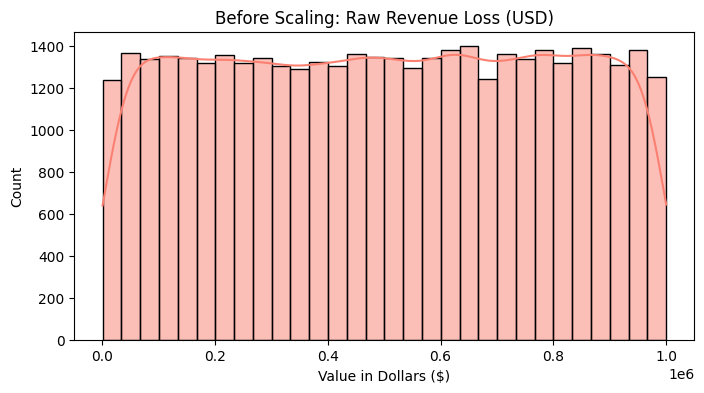

Data split and scaled successfully!
Training features matrix shape: (40000, 70)


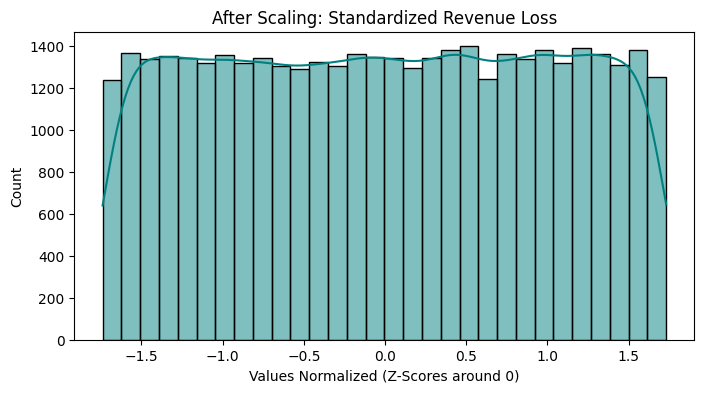

In [44]:
#Setting Target

x = df_encoded.drop(columns=['duration_minutes'])
y = df_encoded['duration_minutes']

# Spliting into 80% Training and 20% Testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 4))
sns.histplot(x_train['estimated_revenue_loss_usd'], bins=30, kde=True, color='salmon')
plt.title('Before Scaling: Raw Revenue Loss (USD)')
plt.xlabel('Value in Dollars ($)')
plt.ylabel('Count')
plt.show()

# Setup scaler and scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Check up

print("Data split and scaled successfully!")
print("Training features matrix shape:", x_train_scaled.shape)

x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns)
plt.figure(figsize=(8, 4))
sns.histplot(x_train_scaled_df['estimated_revenue_loss_usd'], bins=30, kde=True, color='teal')
plt.title('After Scaling: Standardized Revenue Loss')
plt.xlabel('Values Normalized (Z-Scores around 0)')
plt.ylabel('Count')
plt.show()



In [45]:
# Time to Train

model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
print("Model training complete and predictions generated!")

Model training complete and predictions generated!


In [48]:
import numpy as np

# Time to eval

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Results
print("--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Mins")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 42553.46
Root Mean Squared Error (RMSE): 206.28 Mins
R-squared (R2) Score: -0.0009


In [49]:
#Taking another approach than this one R2 = 0.0 is a joke lmao

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(x_train_scaled, y_train)
y_pred_rf = rf_model.predict(x_test_scaled)

In [52]:
# Time to eval

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f} Mins")
print(f"R-squared (R2) Score: {r2_rf:.4f}")

--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 42607.99
Root Mean Squared Error (RMSE): 206.42 Mins
R-squared (R2) Score: -0.0022


In [53]:
# Sampling Data to find the error
sample_columns = ['severity', 'estimated_revenue_loss_usd', 'duration_minutes']
df[sample_columns].sample(15, random_state=42)

,severity,estimated_revenue_loss_usd,duration_minutes
33553,Critical,69910.23,64
9427,Medium,336823.95,368
199,Low,537171.52,484
12447,Critical,430759.35,183
39489,Low,89155.36,499
42724,Critical,933787.28,345
10822,Medium,576612.16,460
49498,Low,973883.48,150
4144,High,463198.39,507
36958,Critical,980249.81,332


In [55]:
#df revewing

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   incident_id                     50000 non-null  object 
 1   cloud_provider                  50000 non-null  object 
 2   region                          50000 non-null  object 
 3   service                         50000 non-null  object 
 4   service_subtype                 50000 non-null  object 
 5   start_time                      50000 non-null  object 
 6   end_time                        50000 non-null  object 
 7   duration_minutes                50000 non-null  int64  
 8   severity                        50000 non-null  object 
 9   status                          50000 non-null  object 
 10  root_cause_category             50000 non-null  object 
 11  root_cause_description          50000 non-null  object 
 12  number_of_customers_affected    

In [56]:
#Quick_CHK

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 71 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   duration_minutes                       50000 non-null  int64  
 1   severity                               50000 non-null  int64  
 2   number_of_customers_affected           50000 non-null  int64  
 3   estimated_revenue_loss_usd             50000 non-null  float64
 4   sla_violation                          50000 non-null  int64  
 5   region_impact_score                    50000 non-null  int64  
 6   service_impact_score                   50000 non-null  int64  
 7   ticket_count                           50000 non-null  int64  
 8   ticket_response_time_minutes           50000 non-null  int64  
 9   ticket_resolution_time_minutes         50000 non-null  int64  
 10  monitoring_alerts_triggered            50000 non-null  int64  
 11  nu

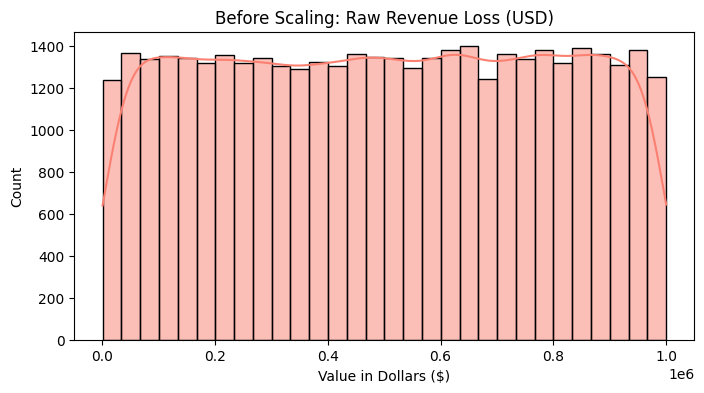

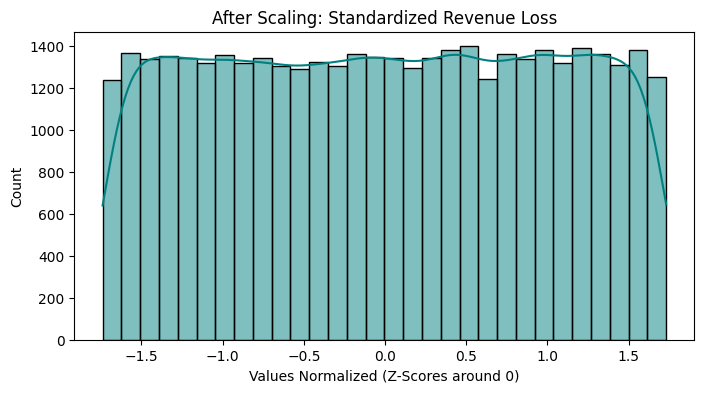

Features updated successfully with impact scores and ticket counts!
New training matrix shape: (40000, 70)


In [58]:
# Re-defining features, making sure to keep our new operational columns

new_features = [
    'estimated_revenue_loss_usd',
    'severity',
    'region_impact_score',
    'service_impact_score',
    'ticket_count',
    'user_feedback_score'
]

feature_cols = [col for col in df_encoded.columns if col !='duration_minutes']
target_col = ['duration_minutes']

x = df_encoded[feature_cols]
y = df_encoded['duration_minutes']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 4))
sns.histplot(x_train['estimated_revenue_loss_usd'], bins=30, kde=True, color='salmon')
plt.title('Before Scaling: Raw Revenue Loss (USD)')
plt.xlabel('Value in Dollars ($)')
plt.ylabel('Count')
plt.show()

# 3. Re-scale everything so the new scores are normalized alongside the raw USD
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns)
plt.figure(figsize=(8, 4))
sns.histplot(x_train_scaled_df['estimated_revenue_loss_usd'], bins=30, kde=True, color='teal')
plt.title('After Scaling: Standardized Revenue Loss')
plt.xlabel('Values Normalized (Z-Scores around 0)')
plt.ylabel('Count')
plt.show()

print("Features updated successfully with impact scores and ticket counts!")
print("New training matrix shape:", x_train_scaled.shape)

In [59]:
# 1. Initialize the Random Forest with our updated feature set
rf_model_v2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Train on the new scaled data containing the impact scores and ticket counts
rf_model_v2.fit(x_train_scaled, y_train)

# 3. Predict the test data
y_pred_rf_v2 = rf_model_v2.predict(x_test_scaled)

# 4. Calculate the updated scores
mse_v2 = mean_squared_error(y_test, y_pred_rf_v2)
rmse_v2 = np.sqrt(mse_v2)
r2_v2 = r2_score(y_test, y_pred_rf_v2)

print("--- Updated Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse_v2:.2f} Mins")
print(f"R-squared (R2) Score: {r2_v2:.4f}")

--- Updated Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): 206.42 Mins
R-squared (R2) Score: -0.0022


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Create a brand new BINARY target (1 = Delayed past 3 hours, 0 = On Time)
y_classification = (df_encoded['duration_minutes'] > 180).astype(int)

# 2. Split the data using the exact same features (X), but our new binary target (y)
x_train, x_test, y_train_cls, y_test_cls = train_test_split(
    x, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

# 3. Re-scale the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Target successfully converted to Classification!")
print(f"Tickets on time (0): {sum(y_classification == 0)}")
print(f"Tickets delayed (1): {sum(y_classification == 1)}")

Target successfully converted to Classification!
Tickets on time (0): 12329
Tickets delayed (1): 37671


In [61]:
#Training time
clf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
clf_model.fit(x_train_scaled, y_train_cls)
y_pred_cls = clf_model.predict(x_test_scaled)
print("--- CLASSIFICATION REPORT ---")
print(f"Overall Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.4f}")
print("\nDetailed Performance:")
print(classification_report(y_test_cls, y_pred_cls))


--- CLASSIFICATION REPORT ---
Overall Accuracy: 0.7534

Detailed Performance:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2466
           1       0.75      1.00      0.86      7534

    accuracy                           0.75     10000
   macro avg       0.38      0.50      0.43     10000
weighted avg       0.57      0.75      0.65     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [62]:
# 1. Initialize the Classifier with the 'balanced' penalty switch activated
clf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Train the model again
clf_balanced.fit(x_train_scaled, y_train_cls)

# 3. Test its new, penalized guesses
y_pred_balanced = clf_balanced.predict(x_test_scaled)

# 4. Print the final truth report
print("--- FINAL BALANCED CLASSIFICATION REPORT ---")
print(f"Overall Accuracy: {accuracy_score(y_test_cls, y_pred_balanced):.4f}")
print("\nDetailed Performance:")
print(classification_report(y_test_cls, y_pred_balanced))

--- FINAL BALANCED CLASSIFICATION REPORT ---
Overall Accuracy: 0.6851

Detailed Performance:
              precision    recall  f1-score   support

           0       0.24      0.12      0.16      2466
           1       0.75      0.87      0.81      7534

    accuracy                           0.69     10000
   macro avg       0.49      0.50      0.48     10000
weighted avg       0.62      0.69      0.65     10000



In [ ]:
#END